# Hospital Inpatient Charges Prediction

Modelling notebook: picks up where `hospital_charges_eda.ipynb` left off. Reads the
cleaned data that notebook wrote to `data/processed/cleanedInpatientCharges.csv` and covers
encoding, train/test split, OLS/Ridge/Lasso fitting, evaluation, and the final write-up

## Load Processed Data

Read the already-cleaned, already-trimmed DataFrame produced by the EDA notebook — no need
to repeat the raw load/clean/drop steps here.

### Imports

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

from insurance_charges_prediction.config import (CLEANED_DATA_FILE,
                                                 RANDOM_STATE,
                                                 TEST_SIZE)

from insurance_charges_prediction.features import (encode_categoricals,
                                                   build_X_y)


from sklearn.model_selection import train_test_split
from sklearn.linear_model import (LinearRegression,
                                  Ridge,
                                  Lasso)
from sklearn.metrics import (r2_score,
                             root_mean_squared_error)
from sklearn.preprocessing import StandardScaler

import math

df = pd.read_csv(CLEANED_DATA_FILE)
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 163065 entries, 0 to 163064
Data columns (total 8 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   DRG Definition                        163065 non-null  str    
 1   Provider City                         163065 non-null  str    
 2   Provider State                        163065 non-null  str    
 3   Hospital Referral Region Description  163065 non-null  str    
 4   Total Discharges                      163065 non-null  int64  
 5   Average Covered Charges               163065 non-null  float64
 6   Average Total Payments                163065 non-null  float64
 7   Average Medicare Payments             163065 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 10.0 MB


,DRG Definition,Provider City,Provider State,Hospital Referral Region Description,Total Discharges,Average Covered Charges,Average Total Payments,Average Medicare Payments
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,DOTHAN,AL,AL - Dothan,91,32963.07,5777.24,4763.73
1,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,BOAZ,AL,AL - Birmingham,14,15131.85,5787.57,4976.71
2,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,FLORENCE,AL,AL - Birmingham,24,37560.37,5434.95,4453.79
3,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,BIRMINGHAM,AL,AL - Birmingham,25,13998.28,5417.56,4129.16
4,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,ALABASTER,AL,AL - Birmingham,18,31633.27,5658.33,4851.44


## One-hot Encoding


In [25]:
df["DRG Definition"].value_counts()

DRG Definition
194 - SIMPLE PNEUMONIA & PLEURISY W CC                                      3023
690 - KIDNEY & URINARY TRACT INFECTIONS W/O MCC                             2989
292 - HEART FAILURE & SHOCK W CC                                            2953
392 - ESOPHAGITIS, GASTROENT & MISC DIGEST DISORDERS W/O MCC                2950
641 - MISC DISORDERS OF NUTRITION,METABOLISM,FLUIDS/ELECTROLYTES W/O MCC    2899
                                                                            ... 
315 - OTHER CIRCULATORY SYSTEM DIAGNOSES W CC                                859
473 - CERVICAL SPINAL FUSION W/O CC/MCC                                      846
917 - POISONING & TOXIC EFFECTS OF DRUGS W MCC                               843
251 - PERC CARDIOVASC PROC W/O CORONARY ARTERY STENT W/O MCC                 727
885 - PSYCHOSES                                                              613
Name: count, Length: 100, dtype: int64

In [26]:
df["DRG Definition"].value_counts().min()

np.int64(613)

In [27]:
encoded_df = encode_categoricals(df)

### Sanity Check

In [28]:
encoded_df.shape

(163065, 149)

In [29]:
encoded_df.head()

,Provider State_AL,Provider State_AR,Provider State_AZ,Provider State_CA,Provider State_CO,Provider State_CT,Provider State_DC,Provider State_DE,Provider State_FL,Provider State_GA,...,DRG Definition_812 - RED BLOOD CELL DISORDERS W/O MCC,DRG Definition_853 - INFECTIOUS & PARASITIC DISEASES W O.R. PROCEDURE W MCC,DRG Definition_870 - SEPTICEMIA OR SEVERE SEPSIS W MV 96+ HOURS,DRG Definition_871 - SEPTICEMIA OR SEVERE SEPSIS W/O MV 96+ HOURS W MCC,DRG Definition_872 - SEPTICEMIA OR SEVERE SEPSIS W/O MV 96+ HOURS W/O MCC,DRG Definition_885 - PSYCHOSES,DRG Definition_897 - ALCOHOL/DRUG ABUSE OR DEPENDENCE W/O REHABILITATION THERAPY W/O MCC,DRG Definition_917 - POISONING & TOXIC EFFECTS OF DRUGS W MCC,DRG Definition_918 - POISONING & TOXIC EFFECTS OF DRUGS W/O MCC,DRG Definition_948 - SIGNS & SYMPTOMS W/O MCC
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


`drop="first"` behaved as expected across all columns

### Encoding Choice
**Provider State** and **DRG Definition** are categorical variables, one-hot encoding was used for both variables

For **Provider State**, direct one-hot encoding made the most sense because there are relatively few states and each category represents a meaningful characteristic that may be associated with differences in hospital charges.

For **DRG Definition** one-hot encoding was also used instead of bucketing. This is because, although there are 100 unique DRG Definitions, the one that appears least frequently appears 613 times, which is still a lot. Therefore, there is no need to combine the less frequent DRG definitions into to obtain more stable estimates.Keeping DRG definitions separate also preserves information about specific inpatient procedures or conditions associated with each observation.

## Set the Dependent and Independent Variables for the Model

In [30]:
X, y = build_X_y(df, encoded_df)

## Train/Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE)

## Fit Linear Regression Model

In [32]:
# Fit the model to train data
model = LinearRegression().fit(X_train, y_train)

# Pair coefficients with columns
coeffs = pd.Series(model.coef_, index=X_train.columns)

# Display intercept and coefficients
print(f"Intercepts: {model.intercept_}")
print(f"coefficient: {coeffs}")

Intercepts: 35886.01699521137
coefficient: Total Discharges                                                                               14.598239
Provider State_AL                                                                           -8468.229049
Provider State_AR                                                                          -14800.333648
Provider State_AZ                                                                           -1471.537322
Provider State_CA                                                                           25069.668675
                                                                                                ...     
DRG Definition_885 - PSYCHOSES                                                             -11698.594109
DRG Definition_897 - ALCOHOL/DRUG ABUSE OR DEPENDENCE W/O REHABILITATION THERAPY W/O MCC   -11967.325389
DRG Definition_917 - POISONING & TOXIC EFFECTS OF DRUGS W MCC                               10075.523832
DRG Definiti

In [33]:
# Display the 10 largest coefficients
coeffs.sort_values(ascending=False).head(10)

DRG Definition_870 - SEPTICEMIA OR SEVERE SEPSIS W MV 96+ HOURS                              132866.122898
DRG Definition_207 - RESPIRATORY SYSTEM DIAGNOSIS W VENTILATOR SUPPORT 96+ HOURS             111023.289494
DRG Definition_853 - INFECTIOUS & PARASITIC DISEASES W O.R. PROCEDURE W MCC                  106865.487824
DRG Definition_329 - MAJOR SMALL & LARGE BOWEL PROCEDURES W MCC                              104105.800556
DRG Definition_460 - SPINAL FUSION EXCEPT CERVICAL W/O MCC                                    64913.778792
DRG Definition_246 - PERC CARDIOVASC PROC W DRUG-ELUTING STENT W MCC OR 4+ VESSELS/STENTS     63868.789372
DRG Definition_238 - MAJOR CARDIOVASC PROCEDURES W/O MCC                                      54499.663709
DRG Definition_469 - MAJOR JOINT REPLACEMENT OR REATTACHMENT OF LOWER EXTREMITY W MCC         52293.626729
DRG Definition_252 - OTHER VASCULAR PROCEDURES W MCC                                          51435.080885
DRG Definition_480 - HIP & FEMUR PROC

In [34]:
# Predictions
y_pred = model.predict(X_test)

## Evaluation Metrics

In [35]:
# Calculate coefficient of determination
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print metrics
print(f"RMSE:                               ${round(rmse, 2)}")
print(f"R² - Coefficient of determination:  {round(r2, 2)}")
print(f"R - Correlation coefficient:        {round(math.sqrt(r2), 2)}")

RMSE:                               $20022.24
R² - Coefficient of determination:  0.67
R - Correlation coefficient:        0.82


### Residual Plot

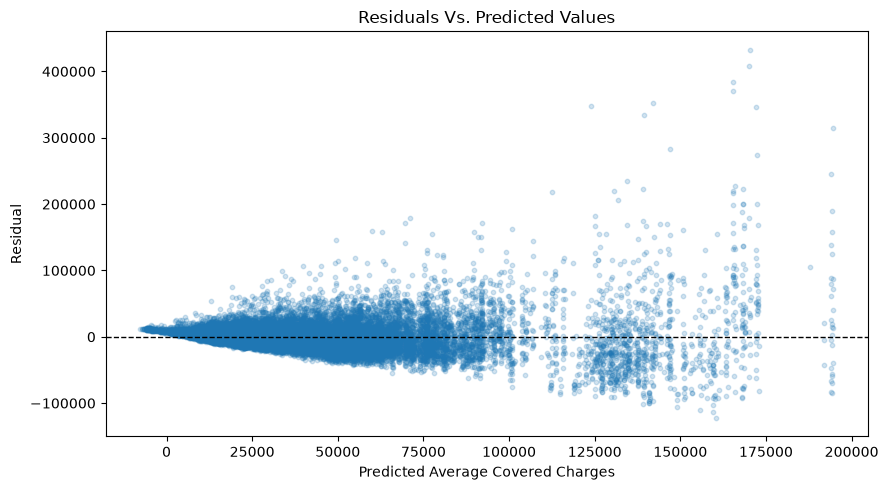

In [36]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred, residuals, alpha=0.2, s=10)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted Average Covered Charges")
ax.set_ylabel("Residual")
ax.set_title("Residuals Vs. Predicted Values")
plt.tight_layout()
plt.show()

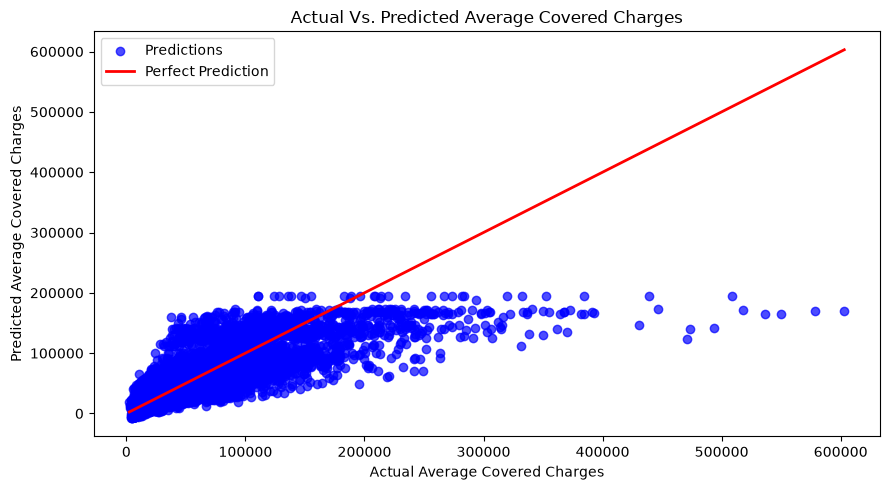

In [37]:
plt.figure(figsize=(9, 5))
plt.scatter(y_test,
            y_pred,
            alpha=0.7,
            color="blue",
            label="Predictions")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    label="Perfect Prediction",
)

plt.title("Actual Vs. Predicted Average Covered Charges")
plt.xlabel("Actual Average Covered Charges")
plt.ylabel("Predicted Average Covered Charges")

plt.legend()
plt.tight_layout()
plt.show()

## Interpretation of Regression Coefficients
The largest positive coefficients are associated with high-acuity DRGs, particularly `DRG 870 – Septicemia or Severe Sepsis with Mechanical Ventilation 96+ Hours (+$132,866)` and `DRG 207 – Respiratory System Diagnosis with Ventilator Support 96+ Hours (+$111,023).` This suggests that clinical complexity and case mix are major sources of charge variation.

State differences are also important. The largest negative coefficients are `Maryland (−$28,210), North Dakota (−$24,455)`, and `West Virginia (−$20,822)`, meaning hospitals in these states have predicted charges substantially lower than the reference state, holding DRG and discharge volume constant. For a payer contracting manager, this suggests that both case mix and geographic differences contribute to variation in hospital charges.


In [38]:
df["Charge to Payment Ratio"] = df["Average Covered Charges"] /df["Average Medicare Payments"]

top5_drg_markup = (
    df.groupby("DRG Definition")["Charge to Payment Ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top5_state_markup = (
    df.groupby("Provider State")["Charge to Payment Ratio"]
    .mean()
    .sort_values(ascending=False)
    .head()
)

print(top5_drg_markup)
print(top5_state_markup)

DRG Definition
313 - CHEST PAIN                                               6.216806
149 - DYSEQUILIBRIUM                                           5.848198
247 - PERC CARDIOVASC PROC W DRUG-ELUTING STENT W/O MCC        5.834388
491 - BACK & NECK PROC EXC SPINAL FUSION W/O CC/MCC            5.826764
249 - PERC CARDIOVASC PROC W NON-DRUG-ELUTING STENT W/O MCC    5.727789
Name: Charge to Payment Ratio, dtype: float64
Provider State
NJ    7.764802
NV    7.407049
FL    6.499863
CA    6.283174
TX    5.636391
Name: Charge to Payment Ratio, dtype: float64


Something important to note is that DRGs with the highest markup ratios, such as `Chest Pain` and `Dysequilibrium`, are not the same as the DRGs with the largest dollar coefficients, such as `Sepsis` and `Respiratory w/Ventilator`.

This is not a contradiction. Lower-cost procedures can have a high charge to payment ratio even when their overall dollar charges are relatively small. In contrast, high-acuity procedures can have much larger absolute charges without necessarily having the highest markup ratios. Therefore, **highest markup** and **largest cost driver** represent two different measures, with the former describing the relative difference between charges and payments, while the latter reflects the absolute dollar impact on costs.

## Average Medicare Payments Model
In this section, the same model is created but this time the target variable is `Average Medicare Payments` instead of `Average Covered Charges`.

In [39]:
# New target variable
y_medicare = df["Average Medicare Payments"]

In [40]:
# Train Test Split
X_train_m, X_test_m, y_train_medicare, y_test_medicare = train_test_split(X,
                                                    y_medicare,
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE)

In [41]:
# Fit the model to train data
medicare_model = LinearRegression().fit(X_train_m, y_train_medicare)

# Pair coefficients with columns
medicare_coeffs = pd.Series(medicare_model.coef_, index=X_train_m.columns)

# Display intercept and coefficients
print(f"Intercepts: {medicare_model.intercept_}")
print(f"coefficient: {medicare_coeffs}")

Intercepts: 10308.340362055442
coefficient: Total Discharges                                                                               1.184513
Provider State_AL                                                                          -6266.161353
Provider State_AR                                                                          -6124.123812
Provider State_AZ                                                                          -4623.682067
Provider State_CA                                                                          -2052.765686
                                                                                               ...     
DRG Definition_885 - PSYCHOSES                                                                78.859313
DRG Definition_897 - ALCOHOL/DRUG ABUSE OR DEPENDENCE W/O REHABILITATION THERAPY W/O MCC   -1864.346452
DRG Definition_917 - POISONING & TOXIC EFFECTS OF DRUGS W MCC                               3978.860782
DRG Definition_918 -

In [42]:
# Predictions
y_pred_medicare = medicare_model.predict(X_test_m)

In [43]:
# Calculate coefficient of determination
medicare_rmse = root_mean_squared_error(y_test_medicare, y_pred_medicare)
medicare_r2 = r2_score(y_test_medicare, y_pred_medicare)

# Print metrics
print(f"RMSE:                               ${round(medicare_rmse, 2)}")
print(f"R² - Coefficient of determination:  {round(medicare_r2, 2)}")
print(f"R - Correlation coefficient:        {round(math.sqrt(medicare_r2), 2)}")

RMSE:                               $2521.97
R² - Coefficient of determination:  0.88
R - Correlation coefficient:        0.94


## Comparison to the Average Covered Charges Model

In [44]:
metrics_comarison_df = pd.DataFrame({
    "Average Covered Charges": [rmse, r2],
    "Average Medicare Payments": [medicare_rmse, medicare_r2]
},  index=["RMSE", "R2"])
print(metrics_comarison_df)

coeff_comparison_df = pd.DataFrame({
    "Charges Coefficient": coeffs,
    "Medicare Coefficient": medicare_coeffs
})
print(coeff_comparison_df.sort_values("Charges Coefficient", ascending=False).head(5))

      Average Covered Charges  Average Medicare Payments
RMSE             20022.235618                2521.970996
R2                   0.667019                   0.878608
                                                    Charges Coefficient  \
DRG Definition_870 - SEPTICEMIA OR SEVERE SEPSI...        132866.122898   
DRG Definition_207 - RESPIRATORY SYSTEM DIAGNOS...        111023.289494   
DRG Definition_853 - INFECTIOUS & PARASITIC DIS...        106865.487824   
DRG Definition_329 - MAJOR SMALL & LARGE BOWEL ...        104105.800556   
DRG Definition_460 - SPINAL FUSION EXCEPT CERVI...         64913.778792   

                                                    Medicare Coefficient  
DRG Definition_870 - SEPTICEMIA OR SEVERE SEPSI...          36112.950109  
DRG Definition_207 - RESPIRATORY SYSTEM DIAGNOS...          30381.352341  
DRG Definition_853 - INFECTIOUS & PARASITIC DIS...          32054.547649  
DRG Definition_329 - MAJOR SMALL & LARGE BOWEL ...          29708.125073  
DRG

## Ridge Vs. Lasso Regression.

**Feature scaling before reqularisation.** `Total Discharges` and the one-hot `Provider State`/`DRG Definition` columns sit on very different scales. Ridge and Lasso penalise coefficient magnitude directly, unscaled features would be regularised unevenly for that aren't related to their actual importance. Both are standardised via `StandardScaler`, fit on the training set only, before fitting Ridge and Lasso. Plain OLS doesn't need this, since its predictions are scale-invariant.

In [45]:
# Instantiate scaler
scaler = StandardScaler()
# Fit scaler to train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
ridge_model = Ridge(random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
lasso_model = Lasso(random_state=RANDOM_STATE, max_iter=5000).fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)
lasso_pred = lasso_model.predict(X_test_scaled)

ridge_rmse = root_mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
lasso_rmse = root_mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

reg_comparison_df = pd.DataFrame({
    "OLS": [rmse, r2],
    "Ridge": [ridge_rmse, ridge_r2],
    "Lasso": [lasso_rmse, lasso_r2]
}, index=["RMSE", "R2"])
print(reg_comparison_df)

ridge_coeffs = pd.Series(ridge_model.coef_, index=X_train.columns)
lasso_coeffs = pd.Series(lasso_model.coef_, index=X_train.columns)

coef_reg_comparison_df = pd.DataFrame({
    "OLS": coeffs,
    "Ridge": ridge_coeffs,
    "Lasso": lasso_coeffs
})
print(coef_reg_comparison_df.sort_values("OLS", ascending=False).head(10))
print("Lasso zeroed-out coefficients:", (lasso_coeffs == 0).sum(), "of", len(lasso_coeffs))

               OLS         Ridge         Lasso
RMSE  20022.235618  20022.230464  20022.438960
R2        0.667019      0.667020      0.667013
                                                              OLS  \
DRG Definition_870 - SEPTICEMIA OR SEVERE SEPSI...  132866.122898   
DRG Definition_207 - RESPIRATORY SYSTEM DIAGNOS...  111023.289494   
DRG Definition_853 - INFECTIOUS & PARASITIC DIS...  106865.487824   
DRG Definition_329 - MAJOR SMALL & LARGE BOWEL ...  104105.800556   
DRG Definition_460 - SPINAL FUSION EXCEPT CERVI...   64913.778792   
DRG Definition_246 - PERC CARDIOVASC PROC W DRU...   63868.789372   
DRG Definition_238 - MAJOR CARDIOVASC PROCEDURE...   54499.663709   
DRG Definition_469 - MAJOR JOINT REPLACEMENT OR...   52293.626729   
DRG Definition_252 - OTHER VASCULAR PROCEDURES ...   51435.080885   
DRG Definition_480 - HIP & FEMUR PROCEDURES EXC...   45674.266692   

                                                          Ridge         Lasso  
DRG Definition_870 

**Worth Noting**

Lasso reduced 0 out of 150 coefficients to zero. It did not remove any features from the model.

This is consistent with the fact that OLS, Ridge and Lasso achieved almost identical $R^2$ scores of 0.667019, 0.667020 and 0.667013, respectively. The minimal difference in performance suggests that the model is not overfitting.

Therefore, regularisation did not change which features were most influential at the default alpha (alpha=1.0).

## Key Findings and Recommendations

The dominant driver of hospital charges is the type of procedure performed. `DRG Definition` alone explains ~54% of the variance in Average Covered Charges, about four times what `Provider State` explains (14%) and the regression's largest coefficients track directly with high-acuity DRGs.

But dollar impact and markup are two different things. The DRGs with the largest coefficients aren't the ones with the highest charge-to-Medicare-payment ratio. Comparatively, low-acuity, high-volume DRGs like Chest Pain (6.2x) and Dysequilibrium (5.8x) carry markups well above what high-acuity DRGs like Sepsis carry — Sepsis, despite having the single largest dollar coefficient, ranks just 89th of 100 DRGs by ratio, at only 3.9x. States like New Jersey (7.8x) and Nevada (7.4x) also charge well above Medicare's benchmark. This ratio is the more useful signal for a payer, it isolates hospital/state pricing behavior on clinically comparable cases, rather than reflecting patient severity.

A second model comparison backs up that this reflects discretion rather than noise. Predicting Average Medicare Payments from the same features reaches $R^2$ = 0.88 (Vs. 0.67 for billed charges), meaning Medicare reimbursement is close to formulaic given DRG, state and volume while billed charges leave nearly a third of their variance unexplained by those same inputs. That gap is consistent with hospitals having latitude in setting list prices that Medicare's payment formula doesn't have.

**Limitation:** the charges model plateaus around `$200k` in its predictions even where actual charges reach `$600k`, systematically underpredicting the priciest cases - expected, given OLS was fit to a right-skewed target (skew is ~4.0, from the EDA notebook) rather than a log-transformed one.

**Recommendation:** payers should target contract negotiations and billing audits using the DRG and state-level charge-to-medicare-payment ratio, not raw charge levels. Hospitals whose ratio sits well above their DRG/state peers can be flagged. This is a more direct lever than acting on total dollar charges, which are driven mostly by legitimate case-mix differences.